BDD-SMALL DATASET EDA FOR TEMPORAL CLASSIFICATION

Sequence Folders (each folder contains frames from one video clip):
  Training: 1360 sequences
  Validation: 276 sequences
  Testing: 555 sequences

Frame Counts:
  Training: 2500 frames
  Validation: 500 frames
  Testing: 1000 frames
  Total: 4000 frames

Label Files Loaded:
  Training sequences: 1360
  Validation sequences: 276

Label Distribution (3-class simplified):
--------------------------------------------------
Training set (2500 frames):
  Red light present:   19.9%
  Green light present: 26.2%
  Road sign present:   58.8%

Validation set (500 frames):
  Red light present:   32.0%
  Green light present: 29.0%
  Road sign present:   64.6%


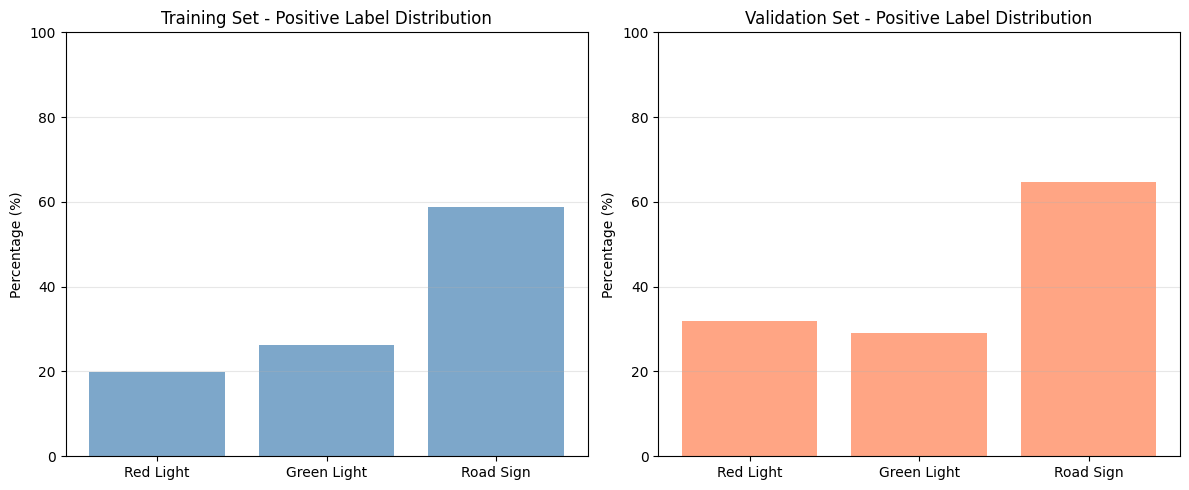

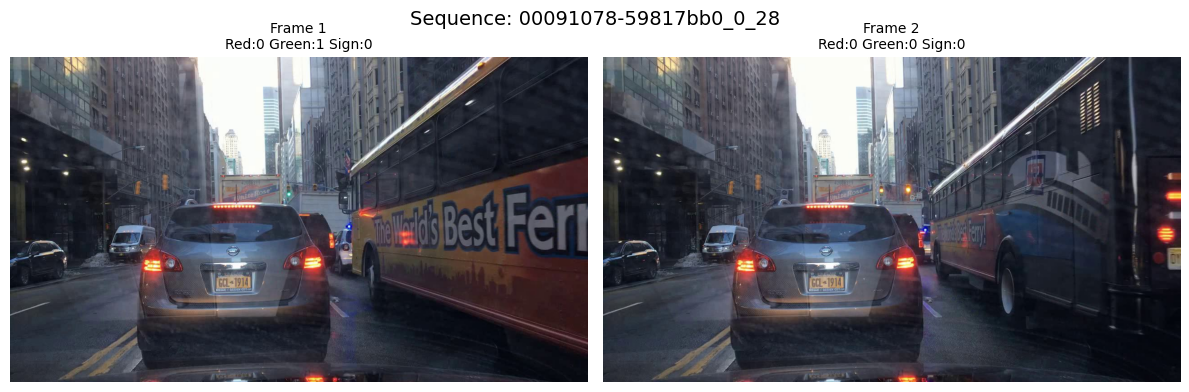

In [17]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

DATA_ROOT = "/kaggle/input/datasets/blossom1994/bdd-small-dataset/input"

print("="*60)
print("BDD-SMALL DATASET EDA FOR TEMPORAL CLASSIFICATION")
print("="*60)

# ============================================
# 1. Dataset Structure Analysis
# ============================================

train_seq_folders = glob.glob(f"{DATA_ROOT}/bdd100k_image/train/*/")
val_seq_folders = glob.glob(f"{DATA_ROOT}/bdd100k_image/val/*/")
test_seq_folders = glob.glob(f"{DATA_ROOT}/bdd100k_image/test/*/")

print(f"\nSequence Folders (each folder contains frames from one video clip):")
print(f"  Training: {len(train_seq_folders)} sequences")
print(f"  Validation: {len(val_seq_folders)} sequences")
print(f"  Testing: {len(test_seq_folders)} sequences")

def count_frames_in_sequences(seq_folders):
    total_frames = 0
    frames_per_seq = []
    for folder in seq_folders:
        frames = glob.glob(f"{folder}*.jpg")
        total_frames += len(frames)
        frames_per_seq.append(len(frames))
    return total_frames, frames_per_seq

train_frames, train_frames_per_seq = count_frames_in_sequences(train_seq_folders)
val_frames, val_frames_per_seq = count_frames_in_sequences(val_seq_folders)
test_frames, test_frames_per_seq = count_frames_in_sequences(test_seq_folders)

print(f"\nFrame Counts:")
print(f"  Training: {train_frames} frames")
print(f"  Validation: {val_frames} frames")
print(f"  Testing: {test_frames} frames")
print(f"  Total: {train_frames + val_frames + test_frames} frames")
# ============================================
# 2. Load Labels
# ============================================

def load_labels(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

train_labels = load_labels(f"{DATA_ROOT}/annotation/trainlabels.json")
val_labels = load_labels(f"{DATA_ROOT}/annotation/vallabels.json")

print(f"\nLabel Files Loaded:")
print(f"  Training sequences: {len(train_labels)}")
print(f"  Validation sequences: {len(val_labels)}")

# ============================================
# 3. Label Distribution Analysis (converted to 3 classes)
# ============================================

def extract_simple_labels(labels_dict):
    """Convert 6-label format to 3-label format: [red, green, sign]"""
    all_labels = []
    for seq_name, frames in labels_dict.items():
        for frame_name, label_list in frames.items():
            simple_labels = [label_list[0], label_list[2], label_list[4]]
            all_labels.append(simple_labels)
    return np.array(all_labels)

train_simple = extract_simple_labels(train_labels)
val_simple = extract_simple_labels(val_labels)

print(f"\nLabel Distribution (3-class simplified):")
print("-"*50)
print(f"Training set ({len(train_simple)} frames):")
print(f"  Red light present:   {train_simple[:, 0].sum() / len(train_simple) * 100:.1f}%")
print(f"  Green light present: {train_simple[:, 1].sum() / len(train_simple) * 100:.1f}%")
print(f"  Road sign present:   {train_simple[:, 2].sum() / len(train_simple) * 100:.1f}%")

print(f"\nValidation set ({len(val_simple)} frames):")
print(f"  Red light present:   {val_simple[:, 0].sum() / len(val_simple) * 100:.1f}%")
print(f"  Green light present: {val_simple[:, 1].sum() / len(val_simple) * 100:.1f}%")
print(f"  Road sign present:   {val_simple[:, 2].sum() / len(val_simple) * 100:.1f}%")

# ============================================
# 4. Visualize Label Distribution
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ['Red Light', 'Green Light', 'Road Sign']
train_percentages = [train_simple[:, 0].mean() * 100, train_simple[:, 1].mean() * 100, train_simple[:, 2].mean() * 100]
val_percentages = [val_simple[:, 0].mean() * 100, val_simple[:, 1].mean() * 100, val_simple[:, 2].mean() * 100]

axes[0].bar(categories, train_percentages, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Training Set - Positive Label Distribution')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(categories, val_percentages, color='coral', alpha=0.7)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Validation Set - Positive Label Distribution')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 5. Visualize Sample Frames with Labels
# ============================================

def visualize_sample_frames(labels_dict, image_root, seq_name, num_frames=2):
    if seq_name not in labels_dict:
        print(f"Sequence {seq_name} not found")
        return
    
    frames = labels_dict[seq_name]
    sorted_frames = sorted(frames.items(), key=lambda x: int(x[0].split('_frame_')[1].split('.')[0]))
    sorted_frames = sorted_frames[:num_frames]
    
    fig, axes = plt.subplots(1, len(sorted_frames), figsize=(12, 4))
    if len(sorted_frames) == 1:
        axes = [axes]
    
    for idx, (frame_name, labels) in enumerate(sorted_frames):
        img_path = os.path.join(image_root, seq_name, frame_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        simple = [labels[0], labels[2], labels[4]]
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"Frame {idx+1}\nRed:{simple[0]} Green:{simple[1]} Sign:{simple[2]}", fontsize=10)
    
    plt.suptitle(f"Sequence: {seq_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

sample_sequence = list(train_labels.keys())[0]
visualize_sample_frames(train_labels, f"{DATA_ROOT}/bdd100k_image/train", sample_sequence, num_frames=2)

In [18]:
# ============================================
# Dataset Class for BDD-Small 
# ============================================

class BDDSmall2FrameDataset(Dataset):
    """
    Dataset that returns exactly 2 frames per sequence
    Skips any sequence that does not have exactly 2 frames
    """
    
    def __init__(self, image_root, label_json_path, transform=None):
        self.image_root = image_root
        
        with open(label_json_path, 'r') as f:
            self.labels = json.load(f)
        
        self.sequences = []
        skipped_count = 0
        
        for seq_name, frames in self.labels.items():
            frame_files = sorted(frames.keys(), key=lambda x: int(x.split('_frame_')[1].split('.')[0]))
            
            if len(frame_files) == 2:
                self.sequences.append({
                    'seq_name': seq_name,
                    'frame_files': frame_files
                })
            else:
                skipped_count += 1
        
        print(f"Loaded {len(self.sequences)} sequences from {image_root}")
        print(f"Skipped {skipped_count} sequences (did not have exactly 2 frames)")
        
        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transform
    
    def __len__(self):
        return len(self.sequences)
    
    def convert_labels(self, label_list):
        """Convert 6-label format to 3-label format: [red, green, sign]"""
        return [label_list[0], label_list[2], label_list[4]]
    
    def __getitem__(self, idx):
        seq_info = self.sequences[idx]
        seq_name = seq_info['seq_name']
        frame_files = seq_info['frame_files']
        
        frames = []
        labels_list = []
        
        for frame_file in frame_files:
            img_path = os.path.join(self.image_root, seq_name, frame_file)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            if self.transform:
                img = self.transform(img)
            
            frames.append(img)
            
            original_labels = self.labels[seq_name][frame_file]
            simple_labels = self.convert_labels(original_labels)
            labels_list.append(simple_labels)
        
        # Stack frames: (2, 3, 224, 224)
        frames_tensor = torch.stack(frames)
        
        # Use the last frame's labels as the sequence label
        sequence_label = torch.tensor(labels_list[-1], dtype=torch.float32)
        
        return frames_tensor, sequence_label, seq_name

In [19]:
# ============================================
# ResNet + LSTM + FC 
# ============================================

class ResNetLSTM(nn.Module):
    """
    ResNet (last 2 layers fine-tuned) -> LSTM -> FC
    Always outputs sequence-level prediction for 2-frame input
    """
    
    def __init__(self, num_classes=3, lstm_hidden_dim=256, lstm_num_layers=2, dropout=0.3):
        super().__init__()
        
        # Load pre-trained ResNet50
        self.resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        
        # Freeze all ResNet layers first
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # Unfreeze last 2 layers (layer3 and layer4)
        for param in self.resnet.layer3.parameters():
            param.requires_grad = True
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True
        
        # Remove classification head, keep up to avgpool
        self.feature_extractor = nn.Sequential(
            *list(self.resnet.children())[:-1]
        )
        
        self.feature_dim = 2048
        
        # LSTM for sequence of 2 frames
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_num_layers,
            batch_first=True,
            dropout=dropout if lstm_num_layers > 1 else 0,
            bidirectional=False
        )
        
        # FC classifier
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        """
        Args:
            x: (B, 2, 3, 224, 224) - Batch of 2-frame sequences
        
        Returns:
            output: (B, num_classes) - Sequence-level predictions
        """
        B, T, C, H, W = x.shape
        
        # Process all frames through ResNet
        x_flat = x.view(B * T, C, H, W)
        features_flat = self.feature_extractor(x_flat)
        features_flat = features_flat.view(B * T, self.feature_dim)
        features_seq = features_flat.view(B, T, self.feature_dim)
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(features_seq)
        
        # Take last hidden state from last layer
        last_hidden = hidden[-1]
        
        # Classify
        output = self.classifier(last_hidden)
        
        return output


# ============================================
# Create DataLoaders 
# ============================================

def create_2frame_dataloaders(batch_size=16, num_workers=2):
    """Create dataloaders for 2-frame sequences only"""
    
    DATA_ROOT = "/kaggle/input/datasets/blossom1994/bdd-small-dataset/input"
    
    train_dataset = BDDSmall2FrameDataset(
        image_root=f"{DATA_ROOT}/bdd100k_image/train",
        label_json_path=f"{DATA_ROOT}/annotation/trainlabels.json"
    )
    
    val_dataset = BDDSmall2FrameDataset(
        image_root=f"{DATA_ROOT}/bdd100k_image/val",
        label_json_path=f"{DATA_ROOT}/annotation/vallabels.json"
    )
    
    test_dataset = BDDSmall2FrameDataset(
        image_root=f"{DATA_ROOT}/bdd100k_image/test",
        label_json_path=f"{DATA_ROOT}/annotation/testlabels.json"
    )
    
    def collate_fn(batch):
        frames = torch.stack([item[0] for item in batch])
        labels = torch.stack([item[1] for item in batch])
        seq_names = [item[2] for item in batch]
        return frames, labels, seq_names
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, collate_fn=collate_fn
    )
    
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, collate_fn=collate_fn
    )
    
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, collate_fn=collate_fn
    )
    
    print(f"\nDataLoaders created (2-frame sequences):")
    print(f"  Train batches: {len(train_loader)}")
    print(f"  Val batches: {len(val_loader)}")
    print(f"  Test batches: {len(test_loader)}")
    print(f"  Batch shape: (B, 2, 3, 224, 224)")
    print(f"  Label shape: (B, 3)")
    
    return train_loader, val_loader, test_loader


# ============================================
# Training Function with AdamW
# ============================================

def train_model(model, train_loader, val_loader, epochs=30, lr=0.001, 
                device='cuda', patience=7, model_save_path='best_model.pth'):
    """
    Train with early stopping and save best model based on validation accuracy
    """
    model = model.to(device)
    
    optimizer = torch.optim.AdamW([
        {'params': model.resnet.layer3.parameters(), 'lr': lr / 10},
        {'params': model.resnet.layer4.parameters(), 'lr': lr / 10},
        {'params': model.lstm.parameters(), 'lr': lr},
        {'params': model.classifier.parameters(), 'lr': lr}
    ], lr=lr, weight_decay=1e-4)
    
    criterion = nn.BCELoss()
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    best_val_acc = 0.0
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for frames, labels, _ in train_loader:
            frames = frames.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(frames)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            preds = (outputs > 0.5).float()
            train_correct += (preds == labels).float().sum().item()
            train_total += labels.numel()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for frames, labels, _ in val_loader:
                frames = frames.to(device)
                labels = labels.to(device)
                
                outputs = model(frames)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).float().sum().item()
                val_total += labels.numel()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1:2d}/{epochs} - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'train_acc': train_acc
            }, model_save_path)
            patience_counter = 0
            print(f"  -> Best model saved (Val Acc: {val_acc:.4f})")
        else:
            patience_counter += 1
            print(f"  -> No improvement. Patience: {patience_counter}/{patience}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after epoch {epoch+1}")
            break
    
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
    return train_losses, val_losses, train_accs, val_accs


In [20]:
from sklearn.metrics import classification_report, confusion_matrix   
import seaborn as sns
def test_model(model, test_loader, device='cuda', model_path='best_model.pth'):
    """
    Load best model and test with 3 confusion matrices (one per class)
    """
    # Load best model
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"\nLoaded best model from epoch {checkpoint['epoch']+1} with Val Acc: {checkpoint['val_acc']:.4f}")
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for frames, labels, _ in test_loader:
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            preds = (outputs > 0.5).int()
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()
    
    class_names = ['Red Light', 'Green Light', 'Road Sign']
    
    print("\n" + "="*50)
    print("TEST RESULTS")
    print("="*50)
    
    # Per-class accuracy
    for i, class_name in enumerate(class_names):
        correct = (all_preds[:, i] == all_labels[:, i]).sum()
        total = len(all_labels)
        acc = correct / total
        print(f"{class_name:15s} - Accuracy: {acc:.4f} ({correct}/{total})")
    
    # Overall metrics
    exact_matches = (all_preds == all_labels).all(axis=1).sum()
    overall_acc = exact_matches / len(all_labels)
    print(f"\nExact Match Accuracy (all 3 correct): {overall_acc:.4f}")
    
    per_label_acc = (all_preds == all_labels).sum(axis=0) / len(all_labels)
    print(f"Per-label Average Accuracy: {per_label_acc.mean():.4f}")
    
    # Classification report
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT (per class)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # 3 confusion matrices (one per class)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, class_name in enumerate(class_names):
        cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'])
        axes[i].set_title(f'Confusion Matrix - {class_name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        
        # Add accuracy text
        acc = (all_preds[:, i] == all_labels[:, i]).sum() / len(all_labels)
        axes[i].text(0.5, -0.15, f'Accuracy: {acc:.3f}', transform=axes[i].transAxes,
                     ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return all_preds, all_labels

RESNET + LSTM FOR 2-FRAME SEQUENCES

Using device: cuda
Loaded 1140 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/train
Skipped 220 sequences (did not have exactly 2 frames)
Loaded 224 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/val
Skipped 52 sequences (did not have exactly 2 frames)
Loaded 445 sequences from /kaggle/input/datasets/blossom1994/bdd-small-dataset/input/bdd100k_image/test
Skipped 110 sequences (did not have exactly 2 frames)

DataLoaders created (2-frame sequences):
  Train batches: 72
  Val batches: 14
  Test batches: 28
  Batch shape: (B, 2, 3, 224, 224)
  Label shape: (B, 3)

Model parameters:
  Total: 28,477,995
  Trainable: 24,984,067

----------------------------------------
TRAINING
----------------------------------------
Epoch  1/30 - Train Loss: 0.5879, Train Acc: 0.7050, Val Loss: 0.6053, Val Acc: 0.6786
  -> Best model saved (Val Acc: 0.6786)
Epoch  2/30 - Train Loss: 0.5238

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


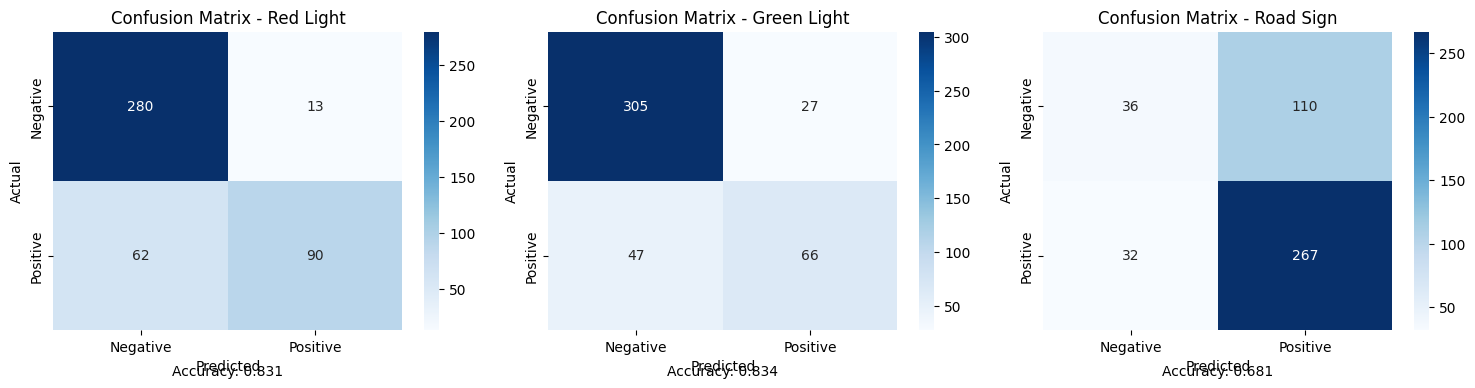

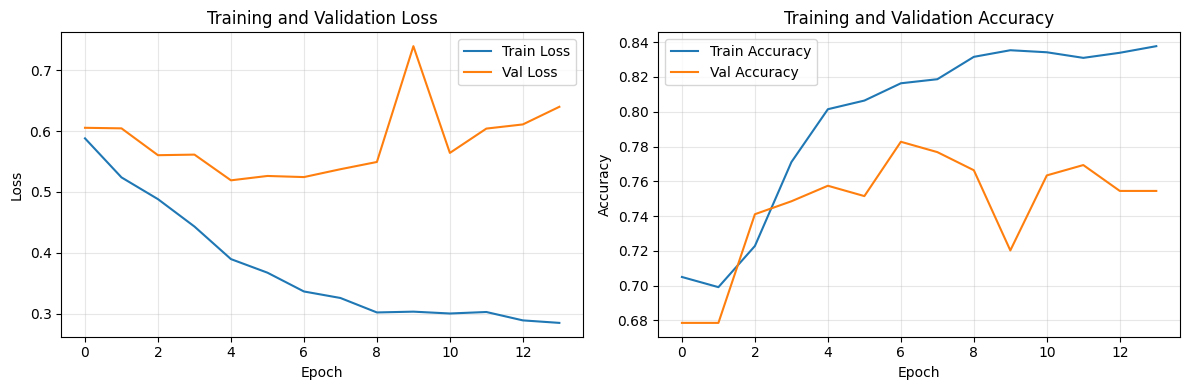

In [21]:
# ============================================
# Main Execution
# ============================================

if __name__ == "__main__":
    
    print("="*60)
    print("RESNET + LSTM FOR 2-FRAME SEQUENCES")
    print("="*60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    
    # Create dataloaders
    train_loader, val_loader, test_loader = create_2frame_dataloaders(batch_size=16)
    
    # Create model
    model = ResNetLSTM(
        num_classes=3,
        lstm_hidden_dim=256,
        lstm_num_layers=2,
        dropout=0.3
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")
    
    # Train with early stopping
    print("\n" + "-"*40)
    print("TRAINING")
    print("-"*40)
    
    train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader,
        epochs=30, lr=0.001, device=device,
        patience=7, model_save_path='best_model.pth'
    )
    
    # Test with confusion matrix
    print("\n" + "-"*40)
    print("TESTING")
    print("-"*40)
    
    test_model(model, test_loader, device=device, model_path='best_model.pth')
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()